In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Automatically detect the CSV dataset in the working directory
csv_files = [f for f in os.listdir('.') if f.endswith(('.csv', '.csv.zip')) or 'Crime_Data' in f]
if not csv_files:
    raise FileNotFoundError("No CSV file found in the project directory. Please check the file path.")

file_path = csv_files[0]
print(f"Loading dataset: {file_path}")

# 2. Read dataset and strip column whitespace
df = pd.read_csv(file_path)
df.columns = df.columns.str.strip()

print(f"Total Raw Records: {df.shape[0]:,}")
print(f"Total Columns: {df.shape[1]}")

# 3. Filter invalid / placeholder coordinates (0.0, 0.0)
# Valid LA County bounds roughly span Lat (33.5 to 34.5) and Lon (-118.8 to -117.5)
df_clean = df[(df['LAT'] > 33.0) & (df['LON'] < -117.0)].copy()

dropped_count = len(df) - len(df_clean)
print(f"\nRemoved {dropped_count:,} records with invalid/zero coordinates.")
print(f"Cleaned Spatial Records: {len(df_clean):,}")

# 4. Feature Engineering: Temporal Dimensions
df_clean['DATE OCC'] = pd.to_datetime(df_clean['DATE OCC'])
df_clean['Year'] = df_clean['DATE OCC'].dt.year
df_clean['Month'] = df_clean['DATE OCC'].dt.month
df_clean['DayOfWeek'] = df_clean['DATE OCC'].dt.day_name()
df_clean['Is_Weekend'] = df_clean['DATE OCC'].dt.dayofweek.apply(lambda x: 1 if x >= 5 else 0)

# Extract hour from military format (e.g., 30 -> '00:30', 2145 -> '21:45')
df_clean['Hour'] = df_clean['TIME OCC'].astype(str).str.zfill(4).str[:2].astype(int)

# 5. Preliminary Exploration
print("\n=== TOP 5 POLICE DIVISIONS BY INCIDENT VOLUME ===")
print(df_clean['AREA NAME'].value_counts().head(5))

print("\n=== TOP 5 MOST FREQUENT CRIME TYPES ===")
print(df_clean['Crm Cd Desc'].value_counts().head(5))

Loading dataset: LA_Crime_Data_from_2020_to_2024.csv
Total Raw Records: 901,357
Total Columns: 28

Removed 2,263 records with invalid/zero coordinates.
Cleaned Spatial Records: 899,094


C:\Users\Prem Ranpise\AppData\Local\Temp\ipykernel_16508\754783674.py:31: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_clean['DATE OCC'] = pd.to_datetime(df_clean['DATE OCC'])



=== TOP 5 POLICE DIVISIONS BY INCIDENT VOLUME ===
AREA NAME
Central        61222
77th Street    56244
Pacific        52364
Southwest      50589
Hollywood      47186
Name: count, dtype: int64

=== TOP 5 MOST FREQUENT CRIME TYPES ===
Crm Cd Desc
VEHICLE - STOLEN            96685
BATTERY - SIMPLE ASSAULT    71292
THEFT OF IDENTITY           55714
BURGLARY FROM VEHICLE       55542
BURGLARY                    55191
Name: count, dtype: int64


In [3]:
# Specifies format handling explicitly to suppress the warning
df_clean['DATE OCC'] = pd.to_datetime(df_clean['DATE OCC'], format='%m/%d/%Y %I:%M:%S %p', errors='coerce')

C:\Users\Prem Ranpise\AppData\Local\Temp\ipykernel_16508\3177486101.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='DayOfWeek', order=days_order, ax=axes[0, 1], palette='Blues_r')
C:\Users\Prem Ranpise\AppData\Local\Temp\ipykernel_16508\3177486101.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_crimes.index, x=top_crimes.values, ax=axes[1, 0], palette='Reds_r')
C:\Users\Prem Ranpise\AppData\Local\Temp\ipykernel_16508\3177486101.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_areas.index, x=top_a

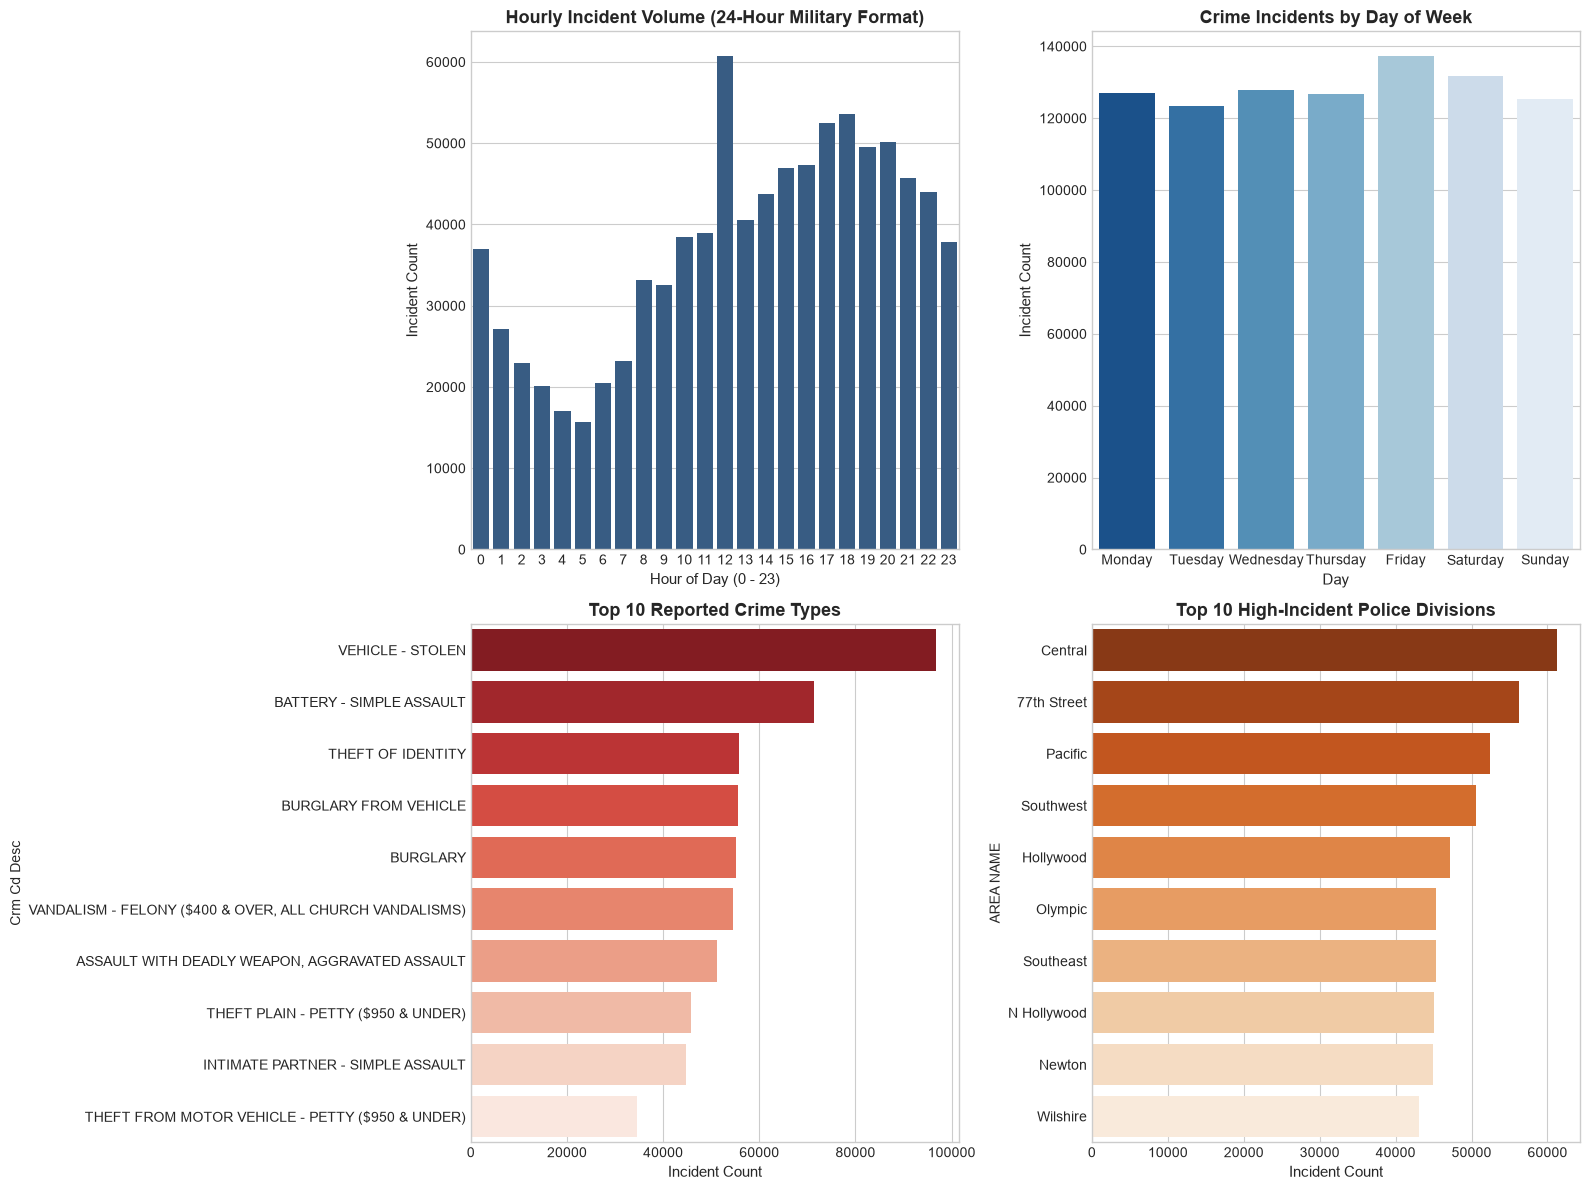

Plots generated and saved as LA_Crime_Temporal_Distribution.png


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visual formatting
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Hourly Crime Volume (24-Hour Distribution)
hourly_counts = df_clean['Hour'].value_counts().sort_index()
sns.barplot(x=hourly_counts.index, y=hourly_counts.values, ax=axes[0, 0], color='#2b5c8f')
axes[0, 0].set_title('Hourly Incident Volume (24-Hour Military Format)', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Hour of Day (0 - 23)', fontsize=11)
axes[0, 0].set_ylabel('Incident Count', fontsize=11)

# 2. Day of Week Pattern
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.countplot(data=df_clean, x='DayOfWeek', order=days_order, ax=axes[0, 1], palette='Blues_r')
axes[0, 1].set_title('Crime Incidents by Day of Week', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Day', fontsize=11)
axes[0, 1].set_ylabel('Incident Count', fontsize=11)

# 3. Top 10 Most Common Crime Classifications
top_crimes = df_clean['Crm Cd Desc'].value_counts().head(10)
sns.barplot(y=top_crimes.index, x=top_crimes.values, ax=axes[1, 0], palette='Reds_r')
axes[1, 0].set_title('Top 10 Reported Crime Types', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Incident Count', fontsize=11)

# 4. Top 10 Police Divisions by Volume
top_areas = df_clean['AREA NAME'].value_counts().head(10)
sns.barplot(y=top_areas.index, x=top_areas.values, ax=axes[1, 1], palette='Oranges_r')
axes[1, 1].set_title('Top 10 High-Incident Police Divisions', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Incident Count', fontsize=11)

plt.tight_layout()
plt.savefig('LA_Crime_Temporal_Distribution.png', dpi=300)
plt.show()
print("Plots generated and saved as LA_Crime_Temporal_Distribution.png")

In [5]:
import folium
from folium.plugins import HeatMap

# Center on Downtown Los Angeles coordinates
la_center = [34.0522, -118.2437]
crime_map = folium.Map(location=la_center, zoom_start=11, tiles='CartoDB dark_matter')

# Sample 50,000 coordinates to optimize HTML rendering speed
heat_sample = df_clean[['LAT', 'LON']].sample(n=min(50000, len(df_clean)), random_state=42).values.tolist()

# Add Kernel Density Heatmap layer
HeatMap(heat_sample, radius=10, blur=14, min_opacity=0.35).add_to(crime_map)

# Save the interactive map file
map_filename = "LA_Crime_Heatmap.html"
crime_map.save(map_filename)
print(f"Interactive map created: {map_filename} (Double click this file in your project folder to open in Chrome/Edge)")

c:\Users\Prem Ranpise\AppData\Local\Programs\Python\Python311\Lib\site-packages\folium\raster_layers.py:130: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tiles = tiles.build_url(fill_subdomain=False, scale_factor="{r}")  # type: ignore


Interactive map created: LA_Crime_Heatmap.html (Double click this file in your project folder to open in Chrome/Edge)


In [6]:
from sklearn.cluster import MiniBatchKMeans

# 1. Extract raw coordinates
coords = df_clean[['LAT', 'LON']].copy()

# 2. Fit MiniBatchKMeans (15 major spatial hotspot centroids across LA)
kmeans = MiniBatchKMeans(n_clusters=15, batch_size=2048, random_state=42)
df_clean['Hotspot_Cluster'] = kmeans.fit_predict(coords)

# 3. Calculate cluster statistics
cluster_summary = df_clean.groupby('Hotspot_Cluster').agg(
    Incidents=('LAT', 'count'),
    Center_Lat=('LAT', 'mean'),
    Center_Lon=('LON', 'mean')
).sort_values(by='Incidents', ascending=False).reset_index()

# Calculate incident share percentage
cluster_summary['Percentage_of_Total'] = (cluster_summary['Incidents'] / len(df_clean) * 100).round(2)

print("=== TOP 5 HIGHEST-DENSITY HOTSPOT CLUSTERS ===")
print(cluster_summary.head(5).to_string(index=False))

# 4. Map the 15 cluster centers onto an interactive map
cluster_map = folium.Map(location=la_center, zoom_start=11, tiles='OpenStreetMap')

for idx, row in cluster_summary.iterrows():
    folium.CircleMarker(
        location=[row['Center_Lat'], row['Center_Lon']],
        radius=float(row['Percentage_of_Total']) * 1.8, # Circle size reflects incident concentration
        popup=f"Cluster {int(row['Hotspot_Cluster'])}: {int(row['Incidents'])} crimes ({row['Percentage_of_Total']}%)",
        color='red',
        fill=True,
        fill_color='crimson',
        fill_opacity=0.65
    ).add_to(cluster_map)

cluster_map.save("LA_Crime_Cluster_Centroids.html")
print("\nCluster map saved as: LA_Crime_Cluster_Centroids.html")

=== TOP 5 HIGHEST-DENSITY HOTSPOT CLUSTERS ===
 Hotspot_Cluster  Incidents  Center_Lat  Center_Lon  Percentage_of_Total
               5     110664   34.041604 -118.244562                12.31
              10      94751   34.077090 -118.289875                10.54
               2      85983   33.953981 -118.274589                 9.56
               0      79031   34.080376 -118.348653                 8.79
               1      77564   34.206625 -118.576195                 8.63

Cluster map saved as: LA_Crime_Cluster_Centroids.html


In [7]:
# Analyze crime distributions within the top 5 hotspot clusters
top_5_cluster_ids = cluster_summary['Hotspot_Cluster'].head(5).values

print("=== CRIME PROFILES FOR TOP 5 HOTSPOT CLUSTERS ===")
for c_id in top_5_cluster_ids:
    cluster_data = df_clean[df_clean['Hotspot_Cluster'] == c_id]
    top_crimes_in_cluster = cluster_data['Crm Cd Desc'].value_counts().head(3)
    pct_share = cluster_summary[cluster_summary['Hotspot_Cluster'] == c_id]['Percentage_of_Total'].values[0]
    
    print(f"\n--- Cluster {c_id} ({pct_share}% of Citywide Crime) ---")
    for crime, count in top_crimes_in_cluster.items():
        print(f"  • {crime}: {count:,} incidents ({count / len(cluster_data) * 100:.1f}%)")

=== CRIME PROFILES FOR TOP 5 HOTSPOT CLUSTERS ===

--- Cluster 5 (12.31% of Citywide Crime) ---
  • BURGLARY FROM VEHICLE: 11,538 incidents (10.4%)
  • VEHICLE - STOLEN: 11,227 incidents (10.1%)
  • BATTERY - SIMPLE ASSAULT: 10,922 incidents (9.9%)

--- Cluster 10 (10.54% of Citywide Crime) ---
  • VEHICLE - STOLEN: 9,540 incidents (10.1%)
  • BATTERY - SIMPLE ASSAULT: 8,179 incidents (8.6%)
  • BURGLARY FROM VEHICLE: 6,514 incidents (6.9%)

--- Cluster 2 (9.56% of Citywide Crime) ---
  • VEHICLE - STOLEN: 11,743 incidents (13.7%)
  • ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT: 8,680 incidents (10.1%)
  • BATTERY - SIMPLE ASSAULT: 7,009 incidents (8.2%)

--- Cluster 0 (8.79% of Citywide Crime) ---
  • BURGLARY FROM VEHICLE: 6,334 incidents (8.0%)
  • BATTERY - SIMPLE ASSAULT: 6,114 incidents (7.7%)
  • BURGLARY: 5,957 incidents (7.5%)

--- Cluster 1 (8.63% of Citywide Crime) ---
  • BURGLARY: 6,524 incidents (8.4%)
  • VEHICLE - STOLEN: 6,434 incidents (8.3%)
  • THEFT OF IDENTITY:

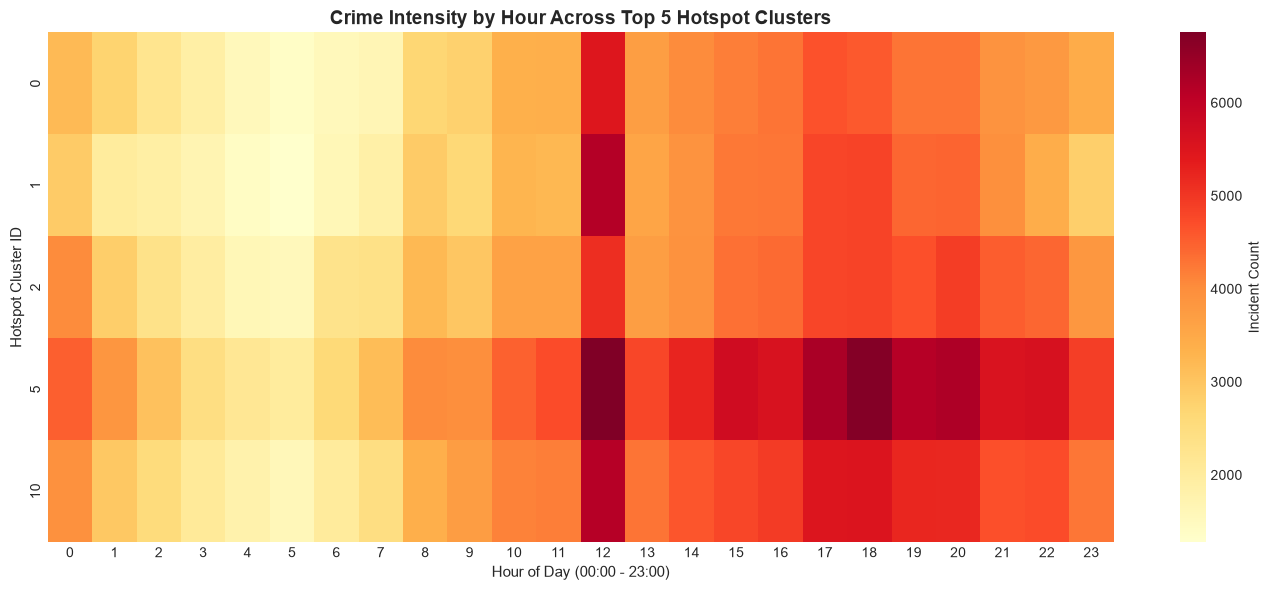

Hourly hotspot distribution plot saved as Hotspot_Hourly_Heatmap.png


In [8]:
# Create a pivot table: Cluster vs Hour of Day
top_clusters_df = df_clean[df_clean['Hotspot_Cluster'].isin(top_5_cluster_ids)]
cluster_hour_pivot = pd.crosstab(top_clusters_df['Hotspot_Cluster'], top_clusters_df['Hour'])

plt.figure(figsize=(14, 6))
sns.heatmap(cluster_hour_pivot, cmap='YlOrRd', annot=False, fmt='d', cbar_kws={'label': 'Incident Count'})
plt.title('Crime Intensity by Hour Across Top 5 Hotspot Clusters', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day (00:00 - 23:00)', fontsize=11)
plt.ylabel('Hotspot Cluster ID', fontsize=11)
plt.tight_layout()
plt.savefig("Hotspot_Hourly_Heatmap.png", dpi=300)
plt.show()

print("Hourly hotspot distribution plot saved as Hotspot_Hourly_Heatmap.png")

Target Distribution:
Is_Violent
0    69.99
1    30.01
Name: proportion, dtype: float64%

Training Samples: 719,275
Testing Samples:  179,819
Selected Decision Threshold: 0.4758

Classification Report (Tuned for Recall):
              precision    recall  f1-score   support

 Non-Violent       0.80      0.50      0.62    125853
     Violent       0.38      0.70      0.49     53966

    accuracy                           0.56    179819
   macro avg       0.59      0.60      0.55    179819
weighted avg       0.67      0.56      0.58    179819

Confusion Matrix:
[[63160 62693]
 [16189 37777]]


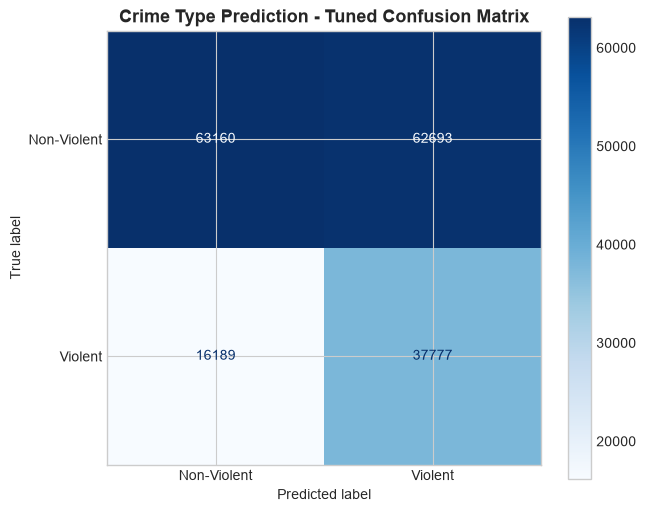

Confusion matrix plot saved as: LA_Crime_Confusion_Matrix.png


In [9]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Define Target Variable: Violent Crime (1) vs Non-Violent / Property Crime (0)
violent_keywords = ['BATTERY', 'ASSAULT', 'ROBBERY', 'HOMICIDE', 'RAPE', 'WEAPON', 'THREAT', 'KIDNAPPING']

pattern = '|'.join(violent_keywords)
df_clean['Is_Violent'] = df_clean['Crm Cd Desc'].str.contains(pattern, case=False, na=False).astype(int)

print(f"Target Distribution:\n{df_clean['Is_Violent'].value_counts(normalize=True).round(4) * 100}%")

# 2. Select predictive features
features = ['LAT', 'LON', 'Hour', 'Month', 'Is_Weekend', 'Hotspot_Cluster']
X = df_clean[features]
y = df_clean['Is_Violent']

# 3. Train-Test Split (80/20 stratified split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"\nTraining Samples: {len(X_train):,}")
print(f"Testing Samples:  {len(X_test):,}")

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve
import numpy as np

# 1. Train classifier with balanced class weights
model = HistGradientBoostingClassifier(
    class_weight='balanced',
    random_state=42
)
model.fit(X_train, y_train)

# 2. Get predicted probabilities instead of default 0.5 cutoffs
y_probs = model.predict_proba(X_test)[:, 1]

# 3. Find optimal decision threshold for recall >= 0.70 (70%)
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)

# Target at least 70% recall on violent crimes
target_recall = 0.70
valid_idx = np.where(recalls >= target_recall)[0]
optimal_threshold = thresholds[valid_idx[-1]] if len(valid_idx) > 0 else 0.5

print(f"Selected Decision Threshold: {optimal_threshold:.4f}\n")

# 4. Generate predictions using the tuned threshold
y_pred_tuned = (y_probs >= optimal_threshold).astype(int)

# 5. Evaluate results
print("Classification Report (Tuned for Recall):")
print(classification_report(y_test, y_pred_tuned, target_names=['Non-Violent', 'Violent']))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned))

# 6. Plot Confusion Matrix (Using Tuned Predictions)
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, y_pred_tuned)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Violent', 'Violent'])
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Crime Type Prediction - Tuned Confusion Matrix', fontsize=13, fontweight='bold')
plt.savefig('LA_Crime_Confusion_Matrix.png', dpi=300)
plt.show()

print("Confusion matrix plot saved as: LA_Crime_Confusion_Matrix.png")

=== FEATURE IMPORTANCE RANKING ===
        Feature  Importance
           Hour    0.011365
     Is_Weekend    0.003851
            LAT    0.002670
            LON    0.001984
          Month    0.001723
Hotspot_Cluster   -0.000092


C:\Users\Prem Ranpise\AppData\Local\Temp\ipykernel_16508\2439395599.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='Blues_r')


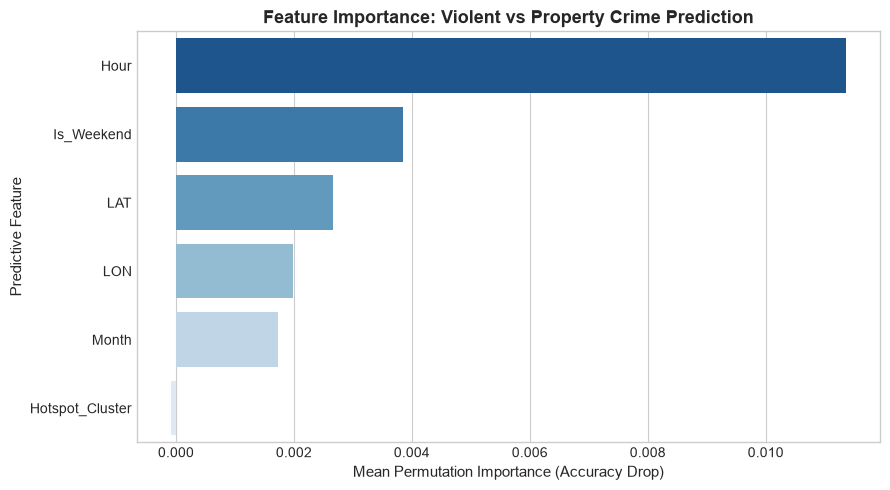


Feature importance plot saved as: LA_Crime_Feature_Importance.png


In [11]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate Permutation Importance on Test Set
result = permutation_importance(model, X_test, y_test, n_repeats=5, random_state=42, n_jobs=-1)

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': result.importances_mean
}).sort_values(by='Importance', ascending=False)

print("=== FEATURE IMPORTANCE RANKING ===")
print(importance_df.to_string(index=False))

# Plot Feature Importance
plt.figure(figsize=(9, 5))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='Blues_r')
plt.title('Feature Importance: Violent vs Property Crime Prediction', fontsize=13, fontweight='bold')
plt.xlabel('Mean Permutation Importance (Accuracy Drop)', fontsize=11)
plt.ylabel('Predictive Feature', fontsize=11)
plt.tight_layout()
plt.savefig('LA_Crime_Feature_Importance.png', dpi=300)
plt.show()

print("\nFeature importance plot saved as: LA_Crime_Feature_Importance.png")

In [12]:
# Export cleaned & clustered dataset for Power BI
export_cols = [
    'DR_NO', 'Date Rptd', 'DATE OCC', 'TIME OCC', 'AREA NAME', 
    'Crm Cd Desc', 'LAT', 'LON', 'Hour', 'Month', 'Is_Weekend', 
    'Hotspot_Cluster', 'Is_Violent'
]

df_clean[export_cols].to_csv('LA_Crime_PowerBI_Ready.csv', index=False)
print("File exported successfully: LA_Crime_PowerBI_Ready.csv")

File exported successfully: LA_Crime_PowerBI_Ready.csv
